# Segmentación de entidades federativas de México según patrones de accidentes de tránsito: el caso de Morelos

**Tema 4 - Análisis de movilidad, transporte o accidentes con datos públicos**

**Equipo:**
- Ruiz Santos Orlando
- Ventura Gil Astrid Valeria
- Ocampo Martínez Angel Daniel
- Medina Villa Abril Aide

**Pregunta guía:** ¿Qué patrones aparecen en los datos de accidentes de tránsito en México, y en qué grupo se ubica Morelos en comparación con las demás entidades federativas?

**Fuente de datos:** Secretaría de Infraestructura, Comunicaciones y Transportes (SICT), publicado en el portal oficial [datos.gob.mx](https://www.datos.gob.mx/dataset/accidentes_transito) bajo licencia Creative Commons Attribution 4.0 (CC-BY-4.0). Ver `referencias/fuentes_datos.txt` para el detalle completo.

Este notebook carga los datos originales, los limpia, construye variables por entidad federativa, realiza un análisis exploratorio y aplica un modelo de agrupamiento (KMeans) para identificar patrones de accidentalidad, con énfasis en el estado de Morelos.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.facecolor'] = 'white'


## 1. Carga del dataset

Se cargan los dos archivos originales descargados de datos.gob.mx (fuente: SICT):
- `sct_70_accidentes_dia.csv`: accidentes por día de la semana y por condición de luz, desagregados por entidad federativa.
- `sct_71_accidentes_mes.csv`: accidentes, heridos, muertos y daños materiales por mes, desagregados por entidad federativa.

In [2]:
dia = pd.read_csv('../data/raw/sct_70_accidentes_dia.csv')
mes = pd.read_csv('../data/raw/sct_71_accidentes_mes.csv')

print('dia:', dia.shape)
print('mes:', mes.shape)
dia.head()


dia: (64, 13)
mes: (384, 6)


,entidad_federativa,accidentes,lunes,martes,miercoles,jueves,viernes,sabado,domingo,luz_dia,luz_crepusculo,luz_noche,luz_alumbrado_publico
0,Aguascalientes,accidentes,34.0,20.0,16.0,23.0,20.0,33.0,33.0,91.0,4.0,84.0,0.0
1,Aguascalientes,accidentes mortales,6.0,4.0,5.0,2.0,3.0,8.0,8.0,13.0,0.0,23.0,0.0
2,Baja California,accidentes,50.0,37.0,36.0,41.0,55.0,75.0,83.0,207.0,15.0,151.0,4.0
3,Baja California,accidentes mortales,8.0,6.0,6.0,6.0,8.0,14.0,16.0,37.0,5.0,22.0,0.0
4,Baja California Sur,accidentes,18.0,29.0,23.0,19.0,35.0,35.0,42.0,102.0,13.0,78.0,8.0


In [3]:
mes.head()

,entidad_federativa,mes,accidentes,danios_materiales_millones,heridos,muertos
0,Aguascalientes,enero,17.0,0.7380,21.0,3.0
1,Aguascalientes,febrero,15.0,0.7130,16.0,2.0
2,Aguascalientes,marzo,14.0,0.3743,10.0,1.0
3,Aguascalientes,abril,13.0,0.4145,7.0,1.0
4,Aguascalientes,mayo,13.0,0.5470,15.0,0.0


## 2. Revisión de columnas

In [4]:
print('Columnas dia:', list(dia.columns))
print(dia.dtypes)
print()
print('Columnas mes:', list(mes.columns))
print(mes.dtypes)


Columnas dia: ['entidad_federativa', 'accidentes', 'lunes', 'martes', 'miercoles', 'jueves', 'viernes', 'sabado', 'domingo', 'luz_dia', 'luz_crepusculo', 'luz_noche', 'luz_alumbrado_publico']
entidad_federativa           str
accidentes                   str
lunes                    float64
martes                   float64
miercoles                float64
jueves                   float64
viernes                  float64
sabado                   float64
domingo                  float64
luz_dia                  float64
luz_crepusculo           float64
luz_noche                float64
luz_alumbrado_publico    float64
dtype: object

Columnas mes: ['entidad_federativa', 'mes', 'accidentes', 'danios_materiales_millones', 'heridos', 'muertos']
entidad_federativa                str
mes                               str
accidentes                    float64
danios_materiales_millones    float64
heridos                       float64
muertos                       float64
dtype: object


## 3. Revisión de nulos y duplicados

In [5]:
print('Nulos en dia:')
print(dia.isnull().sum())
print()
print('Nulos en mes:')
print(mes.isnull().sum())
print()
print('Filas duplicadas en dia:', dia.duplicated().sum())
print('Filas duplicadas en mes:', mes.duplicated().sum())
print()
print('Entidades en dia:', dia['entidad_federativa'].nunique())
print('Entidades en mes:', mes['entidad_federativa'].nunique())


Nulos en dia:
entidad_federativa       0
accidentes               0
lunes                    0
martes                   0
miercoles                0
jueves                   0
viernes                  0
sabado                   0
domingo                  0
luz_dia                  0
luz_crepusculo           0
luz_noche                0
luz_alumbrado_publico    0
dtype: int64

Nulos en mes:
entidad_federativa            0
mes                           0
accidentes                    0
danios_materiales_millones    0
heridos                       0
muertos                       0
dtype: int64

Filas duplicadas en dia: 0
Filas duplicadas en mes: 0

Entidades en dia: 32
Entidades en mes: 32


No se encontraron valores nulos ni filas duplicadas. Ambos archivos cubren las 32 entidades federativas de México. La columna `accidentes` en el archivo por día en realidad es una etiqueta de tipo de fila (`"accidentes"` = total, `"accidentes mortales"` = subconjunto mortal), no un conteo, por lo que se trata como variable categórica en la limpieza.

## 4. Limpieza básica

In [6]:
dia.columns = [c.strip().lower() for c in dia.columns]
mes.columns = [c.strip().lower() for c in mes.columns]
dia['entidad_federativa'] = dia['entidad_federativa'].str.strip()
mes['entidad_federativa'] = mes['entidad_federativa'].str.strip()

# Se homologan nombres de entidades a la forma estandar usada por INEGI
rename_map = {
    'Ciudad De Mexico': 'Ciudad de Mexico',
    'Estado Mexico': 'Estado de Mexico',
}
dia['entidad_federativa'] = dia['entidad_federativa'].replace(rename_map)
mes['entidad_federativa'] = mes['entidad_federativa'].replace(rename_map)

# Se separan los registros de accidentes totales y accidentes mortales (dataset por dia)
dia_tot = dia[dia['accidentes'] == 'accidentes'].copy()
dia_tot.head()


,entidad_federativa,accidentes,lunes,martes,miercoles,jueves,viernes,sabado,domingo,luz_dia,luz_crepusculo,luz_noche,luz_alumbrado_publico
0,Aguascalientes,accidentes,34.0,20.0,16.0,23.0,20.0,33.0,33.0,91.0,4.0,84.0,0.0
2,Baja California,accidentes,50.0,37.0,36.0,41.0,55.0,75.0,83.0,207.0,15.0,151.0,4.0
4,Baja California Sur,accidentes,18.0,29.0,23.0,19.0,35.0,35.0,42.0,102.0,13.0,78.0,8.0
6,Campeche,accidentes,27.0,32.0,29.0,17.0,29.0,24.0,37.0,98.0,3.0,94.0,0.0
8,Chiapas,accidentes,100.0,80.0,96.0,107.0,90.0,108.0,95.0,358.0,23.0,294.0,1.0


## 5. Selección y construcción de variables

Los datos originales están a nivel de conteos por día de la semana, condición de luz, y mes. Para comparar entidades de tamaño distinto (por ejemplo, Ciudad de México vs Colima) se construyen **tasas y proporciones** en lugar de usar solo totales, ya que el objetivo es comparar *patrones*, no solo volumen:

- `tasa_letalidad`: muertos por cada 100 accidentes registrados en el año (severidad).
- `tasa_heridos`: heridos por cada 100 accidentes (severidad).
- `pct_fin_de_semana`: proporción de accidentes ocurridos sábado o domingo (patrón temporal semanal).
- `pct_nocturno`: proporción de accidentes ocurridos en condición de luz crepuscular o nocturna (patrón horario).

También se conservan `accidentes_anual`, `heridos_anual`, `muertos_anual` y `danios_millones_anual` como variables descriptivas (no se usan directamente en el modelo, para evitar que el tamaño del estado domine el agrupamiento).

In [7]:
dias_semana = ['lunes','martes','miercoles','jueves','viernes','sabado','domingo']
dia_tot['total_dia'] = dia_tot[dias_semana].sum(axis=1)
dia_tot['pct_fin_de_semana'] = (dia_tot['sabado'] + dia_tot['domingo']) / dia_tot['total_dia']

luz_cols = ['luz_dia','luz_crepusculo','luz_noche','luz_alumbrado_publico']
dia_tot['total_luz'] = dia_tot[luz_cols].sum(axis=1)
dia_tot['pct_nocturno'] = (dia_tot['luz_noche'] + dia_tot['luz_crepusculo']) / dia_tot['total_luz']

dia_feat = dia_tot[['entidad_federativa','pct_fin_de_semana','pct_nocturno']]

mes_agg = mes.groupby('entidad_federativa', as_index=False).agg(
    accidentes_anual=('accidentes','sum'),
    heridos_anual=('heridos','sum'),
    muertos_anual=('muertos','sum'),
    danios_millones_anual=('danios_materiales_millones','sum'),
)
mes_agg['tasa_letalidad'] = mes_agg['muertos_anual'] / mes_agg['accidentes_anual'] * 100
mes_agg['tasa_heridos'] = mes_agg['heridos_anual'] / mes_agg['accidentes_anual'] * 100

df = mes_agg.merge(dia_feat, on='entidad_federativa', how='inner')
print(df.shape)
df.to_csv('../data/processed/dataset_limpio.csv', index=False, encoding='utf-8-sig')
df.head()


(32, 9)


,entidad_federativa,accidentes_anual,heridos_anual,muertos_anual,danios_millones_anual,tasa_letalidad,tasa_heridos,pct_fin_de_semana,pct_nocturno
0,Aguascalientes,179.0,200.0,49.0,10.3270,27.374302,111.731844,0.368715,0.491620
1,Baja California,377.0,239.0,83.0,22.5462,22.015915,63.395225,0.419098,0.440318
2,Baja California Sur,201.0,140.0,47.0,9.5933,23.383085,69.651741,0.383085,0.452736
3,Campeche,195.0,112.0,33.0,16.9182,16.923077,57.435897,0.312821,0.497436
4,Chiapas,676.0,421.0,116.0,48.8681,17.159763,62.278107,0.300296,0.468935


## 6. Análisis exploratorio (EDA)

In [8]:
df[['accidentes_anual','heridos_anual','muertos_anual','tasa_letalidad','tasa_heridos','pct_fin_de_semana','pct_nocturno']].describe().round(2)


,accidentes_anual,heridos_anual,muertos_anual,tasa_letalidad,tasa_heridos,pct_fin_de_semana,pct_nocturno
count,32.00,32.00,32.00,32.00,32.00,32.00,32.00
mean,371.03,278.28,91.22,24.55,77.57,0.37,0.46
std,228.70,175.99,59.90,8.23,24.00,0.05,0.04
min,67.00,78.00,16.00,6.72,37.30,0.28,0.37
25%,201.00,154.50,48.50,19.21,60.85,0.35,0.44
50%,337.00,270.00,78.50,25.29,70.12,0.37,0.46
75%,453.00,313.00,125.50,31.20,94.76,0.37,0.49
max,1290.00,891.00,269.00,40.35,130.67,0.49,0.55


In [9]:
print('Promedio nacional tasa_letalidad:', round(df['tasa_letalidad'].mean(), 2))
print('Promedio nacional pct_fin_de_semana:', round(df['pct_fin_de_semana'].mean(), 3))
print('Promedio nacional pct_nocturno:', round(df['pct_nocturno'].mean(), 3))
print()
print('Fila de Morelos:')
df[df['entidad_federativa'] == 'Morelos']


Promedio nacional tasa_letalidad: 24.55
Promedio nacional pct_fin_de_semana: 0.366
Promedio nacional pct_nocturno: 0.461

Fila de Morelos:


,entidad_federativa,accidentes_anual,heridos_anual,muertos_anual,danios_millones_anual,tasa_letalidad,tasa_heridos,pct_fin_de_semana,pct_nocturno
16,Morelos,201.0,118.0,23.0,18.4208,11.442786,58.706468,0.477612,0.547264


**Gráfica 1.** Total de accidentes registrados en el año por entidad federativa, ordenados de mayor a menor. Morelos se resalta para ubicar su volumen relativo dentro del contexto nacional.

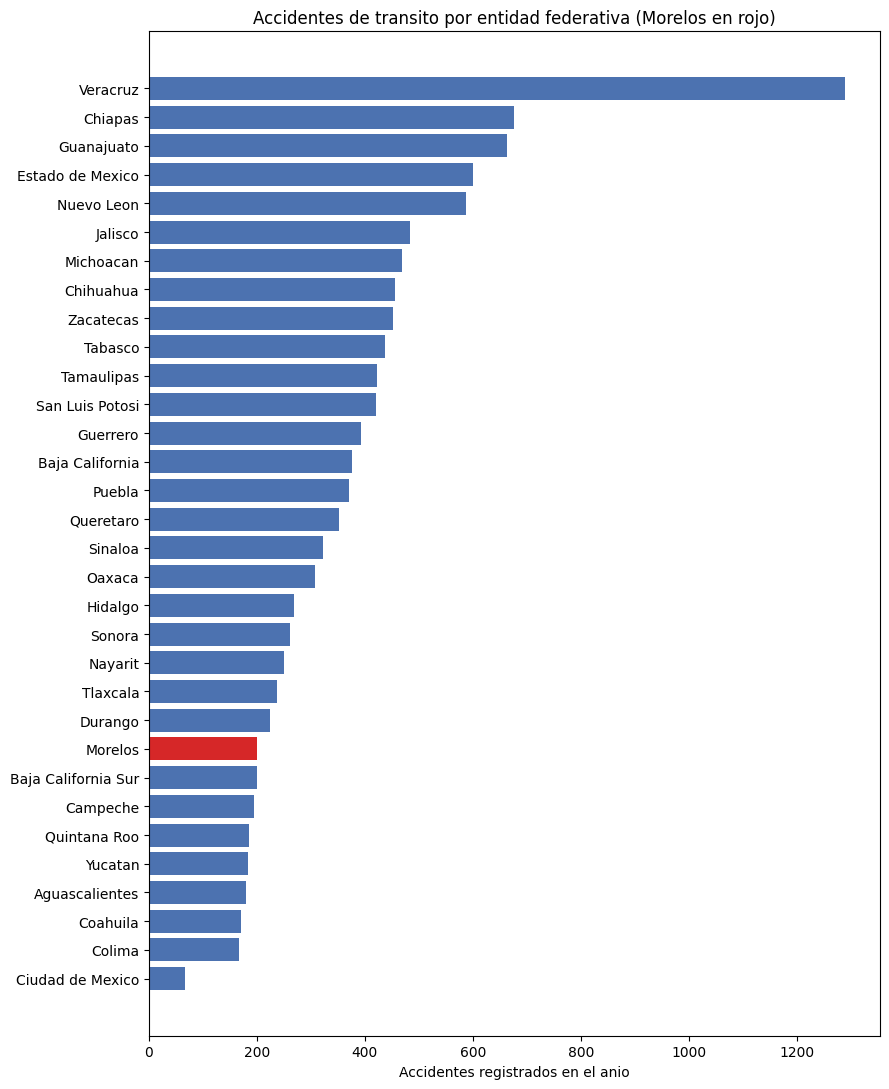

In [10]:
df_sorted = df.sort_values('accidentes_anual', ascending=True)
colors = ['#d62728' if e == 'Morelos' else '#4C72B0' for e in df_sorted['entidad_federativa']]

fig, ax = plt.subplots(figsize=(9, 11))
ax.barh(df_sorted['entidad_federativa'], df_sorted['accidentes_anual'], color=colors)
ax.set_xlabel('Accidentes registrados en el anio')
ax.set_title('Accidentes de transito por entidad federativa (Morelos en rojo)')
plt.tight_layout()
plt.savefig('../imagenes/grafica_1.png', dpi=150)
plt.show()


La gráfica muestra que Morelos se ubica en una posición intermedia-baja en volumen total de accidentes registrados (puesto 24 de 32), lo cual es consistente con su tamaño poblacional y territorial frente a entidades como el Estado de México o Ciudad de México. Este resultado por sí solo no dice mucho sobre el *patrón* de los accidentes, por lo que se complementa con las variables de tasa y proporción definidas antes.

## 7. Metodología del modelo

Se aplica **KMeans** (aprendizaje no supervisado) porque no existe una etiqueta previa de "grupo" para las entidades; el objetivo es descubrir qué estados comparten un patrón similar de accidentalidad. Se usan 4 variables estandarizadas (media 0, desviación 1) para que ninguna domine por su escala:

`tasa_letalidad`, `tasa_heridos`, `pct_fin_de_semana`, `pct_nocturno`.

El número de grupos *k* se explora con el coeficiente de silueta (silhouette score) para valores de k entre 2 y 6.

In [11]:
features = ['tasa_letalidad', 'tasa_heridos', 'pct_fin_de_semana', 'pct_nocturno']
X = df[features].values
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

resultados_k = []
for k in range(2, 7):
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km_k.fit_predict(Xs)
    sil = silhouette_score(Xs, labels_k)
    resultados_k.append((k, round(sil, 3)))

pd.DataFrame(resultados_k, columns=['k', 'silhouette'])


,k,silhouette
0,2,0.248
1,3,0.258
2,4,0.246
3,5,0.285
4,6,0.299


Ningún valor de *k* produce una separación muy marcada (silhouette entre 0.246 y 0.299), lo cual es esperable con solo 32 observaciones y variables de comportamiento social. Los puntajes más altos de la tabla corresponden a k=6 (0.299) y k=5 (0.285), ambos por encima de k=3 (0.258). Aun así se elige **k = 3**, por dos razones. Primera: en muestras pequeñas y sin una estructura de grupos marcada, el coeficiente de silueta tiende a subir de forma mecánica conforme aumenta *k*, porque los grupos se vuelven más chicos y compactos por construcción; esa ganancia no es evidencia de un mejor agrupamiento real. Segunda: con 32 entidades, k=6 produce grupos de alrededor de cinco estados cada uno, demasiado pequeños para sostener la descripción de un patrón de accidentalidad generalizable. La diferencia de 0.041 puntos de silueta entre k=3 y k=6 no compensa esa pérdida de interpretabilidad, que es justamente el objetivo del análisis.

In [12]:
k_final = 3
km = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(Xs)

print('Entidades por cluster:')
print(df['cluster'].value_counts().sort_index())
print()
print('Cluster asignado a Morelos:', df.loc[df['entidad_federativa'] == 'Morelos', 'cluster'].values[0])


Entidades por cluster:
cluster
0    15
1    11
2     6
Name: count, dtype: int64

Cluster asignado a Morelos: 0


## 8. Resultados del modelo

In [13]:
resumen = df.groupby('cluster')[features + ['accidentes_anual', 'muertos_anual']].mean().round(2)
resumen['n_entidades'] = df['cluster'].value_counts().sort_index()
resumen.to_csv('../outputs/resumen_resultados.csv', encoding='utf-8-sig')

df_out = df[['entidad_federativa', 'accidentes_anual', 'heridos_anual', 'muertos_anual',
             'tasa_letalidad', 'tasa_heridos', 'pct_fin_de_semana', 'pct_nocturno', 'cluster']].sort_values('cluster')
df_out.to_csv('../outputs/resultados_modelo.csv', index=False, encoding='utf-8-sig')

resumen


,tasa_letalidad,tasa_heridos,pct_fin_de_semana,pct_nocturno,accidentes_anual,muertos_anual,n_entidades
cluster,,,,,,,
0,27.82,73.00,0.39,0.48,372.67,108.27,15
1,16.50,65.55,0.33,0.47,425.82,74.36,11
2,31.15,111.01,0.38,0.40,266.50,79.50,6


In [14]:
df[df['cluster'] == df.loc[df['entidad_federativa'] == 'Morelos', 'cluster'].values[0]][
    ['entidad_federativa', 'tasa_letalidad', 'pct_fin_de_semana', 'pct_nocturno']
].sort_values('pct_nocturno', ascending=False)


,entidad_federativa,tasa_letalidad,pct_fin_de_semana,pct_nocturno
16,Morelos,11.442786,0.477612,0.547264
10,Estado de Mexico,32.445923,0.339434,0.504160
11,Guanajuato,28.657617,0.386124,0.500754
12,Guerrero,33.333333,0.371501,0.498728
13,Hidalgo,21.641791,0.369403,0.496269
20,Puebla,32.884097,0.382749,0.493261
0,Aguascalientes,27.374302,0.368715,0.491620
22,Quintana Roo,28.108108,0.351351,0.486486
24,Sinaloa,29.813665,0.394410,0.481366
14,Jalisco,38.016529,0.365702,0.477273


**Gráfica 2.** Entidades federativas según proporción de accidentes en fin de semana (eje X) y proporción de accidentes en horario nocturno/crepuscular (eje Y), coloreadas por cluster. Morelos se marca con una estrella negra.

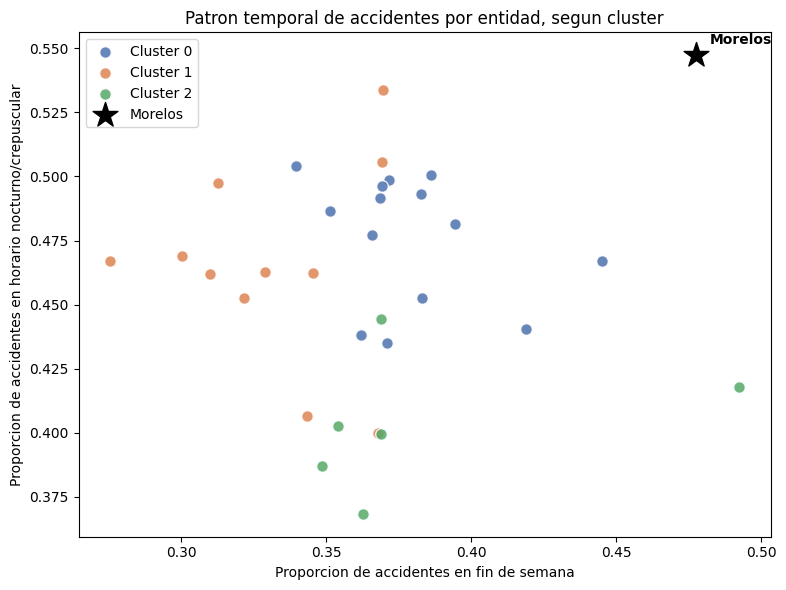

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
colores_cluster = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868'}
for c in sorted(df['cluster'].unique()):
    sub = df[df['cluster'] == c]
    ax.scatter(sub['pct_fin_de_semana'], sub['pct_nocturno'], label=f'Cluster {c}',
               color=colores_cluster[c], s=70, alpha=0.85, edgecolor='white')

morelos = df[df['entidad_federativa'] == 'Morelos'].iloc[0]
ax.scatter(morelos['pct_fin_de_semana'], morelos['pct_nocturno'], color='black', marker='*',
           s=350, label='Morelos', zorder=5)
ax.annotate('Morelos', (morelos['pct_fin_de_semana'], morelos['pct_nocturno']),
            textcoords='offset points', xytext=(10, 8), fontsize=10, fontweight='bold')

ax.set_xlabel('Proporcion de accidentes en fin de semana')
ax.set_ylabel('Proporcion de accidentes en horario nocturno/crepuscular')
ax.set_title('Patron temporal de accidentes por entidad, segun cluster')
ax.legend()
plt.tight_layout()
plt.savefig('../imagenes/grafica_2.png', dpi=150)
plt.show()


## 9. Interpretación de resultados

Morelos queda agrupado en el **cluster 0** (15 entidades), junto con estados como Jalisco, Guerrero, Puebla, Guanajuato y el Estado de México, entre otros. Sin embargo, la razón por la que Morelos cae en ese grupo **no es su nivel de letalidad**: con datos disponibles se observa que la tasa de letalidad de Morelos (accidentes mortales por cada 100 accidentes) es una de las más bajas de las 32 entidades (alrededor de 11.4, frente a un promedio nacional cercano a 24.6), mientras que varios de sus compañeros de cluster (Jalisco, Guerrero, Puebla) tienen tasas de letalidad mucho más altas (30-38).

Lo que sí comparte Morelos con ese grupo -y lo que en la práctica define su pertenencia al cluster- es un **patrón temporal marcado**: Morelos tiene la proporción más alta de accidentes en horario nocturno o crepuscular de las 32 entidades (aproximadamente 54.7%, frente a un promedio nacional de 46.1%), y también una de las proporciones más altas de accidentes concentrados en fin de semana (sábado y domingo), alrededor de 47.8% frente a un promedio nacional de 36.6%.

En otras palabras, con los datos disponibles se observa que **el perfil distintivo de Morelos no es la severidad de sus accidentes, sino su concentración temporal**: una proporción inusualmente alta ocurre de noche y en fin de semana. Este resultado sugiere una posible relación con patrones de movilidad nocturna/recreativa de fin de semana, pero esto **no puede afirmarse como causal** con la información agregada disponible; solo se observa una asociación descriptiva.

## 10. Limitaciones

- **Nivel de agregación:** los datos están agregados por entidad federativa (32 registros), no por municipio, por lo que no es posible analizar diferencias internas entre municipios de Morelos con esta fuente.
- **Periodo no explicitado con precisión:** los metadatos públicos del recurso en datos.gob.mx no indican de forma explícita el año exacto de referencia de los registros (el conjunto fue publicado por la SICT en julio de 2025); se asume que corresponde a un periodo anual reciente, pero esto debe confirmarse con la fuente antes de usarse en un contexto donde la fecha exacta sea crítica.
- **Pocos datos para el modelo:** el agrupamiento se realiza sobre solo 32 observaciones (una por entidad), lo cual limita la robustez estadística de los clusters; el coeficiente de silueta obtenido (~0.26-0.30) indica una separación moderada, no fuertemente marcada.
- **Variables faltantes:** no se cuenta con información de tipo de vehículo, zona urbana/suburbana específica, ni causa del accidente, variables que el tema sugiere y que podrían enriquecer el análisis si estuvieran disponibles a este nivel de agregación.
- **Sin causalidad:** el modelo agrupa entidades por similitud estadística; no demuestra que el horario nocturno o el fin de semana *causen* más accidentes en Morelos, solo que están asociados en los datos observados.
- **Dependencia de las variables elegidas:** los grupos de KMeans dependen directamente de qué variables se seleccionaron (tasa_letalidad, tasa_heridos, pct_fin_de_semana, pct_nocturno); usar otras variables (por ejemplo, tipo de vehículo o zona) podría producir una segmentación distinta.